<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/group_exercises/exercise_5/Group_Exercise_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Group Exercise – Chapter 3 Time Series Analysis**

**Group Exercise 5**

Group consisting of Ritu, Vikrant Singh and Kay Müller

Dataset: Wikipedia API - Daily stone views Wikipedia page "Machine learning"

Source: https://en.wikipedia.org/wiki/Machine_learning

Data characteristics:

*   Time-dependent data (page views per day)
*   Seasonality (weekly)
*   Trends in terms of interest in content
*   Time steps over an entire year

Further sources/references (specifically SARIMA bzw. SARIMAX):

https://www.statsmodels.org/stable/examples/notebooks/generated/statespace_sarimax_stata.html

https://otexts.com/fpp3/arima.html



In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:

# Source API-Structure: https://doc.wikimedia.org/generated-data-platform/aqs/analytics-api/examples/project-metrics.html
# Article-Basic: https://en.wikipedia.org/wiki/Machine_learning
# Retrieve article: Machine_learning; period 01.01.2025 to 31.12.2025

url = (
    "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
    "en.wikipedia/all-access/all-agents/Machine_learning/daily/20250101/20251231"
)

# Specify user agent to communicate our project/purpose
headers = {"User-Agent": "Statistics and Machine Learning (Student project)"}
response = requests.get(url, headers=headers)
data_j = response.json()
records = data_j["items"]
df = pd.DataFrame(records)  # to DataFrame
df["date"] = pd.to_datetime(df["timestamp"], format="%Y%m%d00")
df = df.set_index("date")
df = df[["views"]]          # only views
df.index.freq = "D"         # time series index

print(f"Number of time steps: {len(df)}")
print(f"Period: {df.index.min().date()} to {df.index.max().date()}")
df.head(400)

Number of time steps: 365
Period: 2025-01-01 to 2025-12-31


,views
date,
2025-01-01,4802
2025-01-02,5712
2025-01-03,6034
2025-01-04,4893
2025-01-05,4513
...,...
2025-12-27,3090
2025-12-28,3010
2025-12-29,3888


##1. Plot the Time Series
Line plot of the raw data

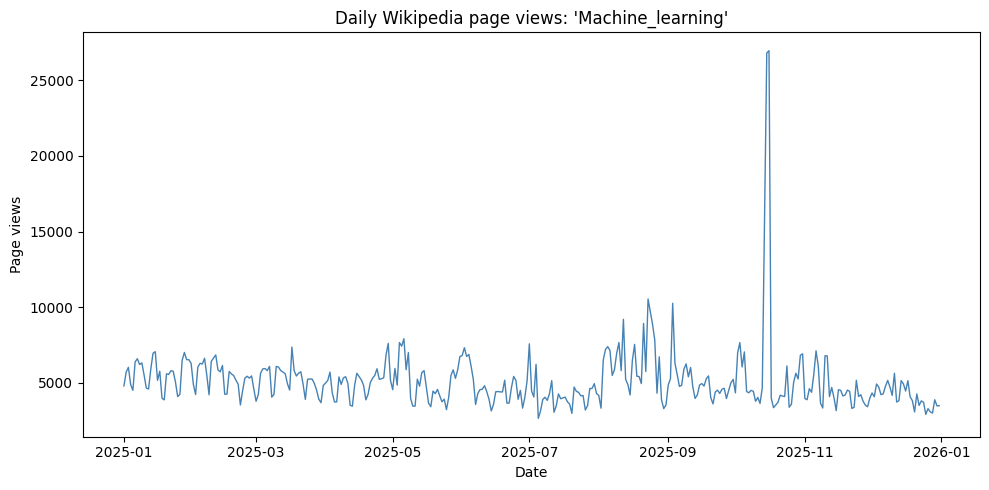

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["views"], color="steelblue", linewidth=1)
plt.title(f"Daily Wikipedia page views: 'Machine_learning'", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Page views")
plt.tight_layout()
plt.show()

Interpretation:

The time series from the page views per day allows us to observe temporal order and sequence. A trend over time can be seen, as well as a shock in the last quarter.

##2. Time Series Decomposition
Decompose into:
Trend;
Seasonality;
Residual (noise)

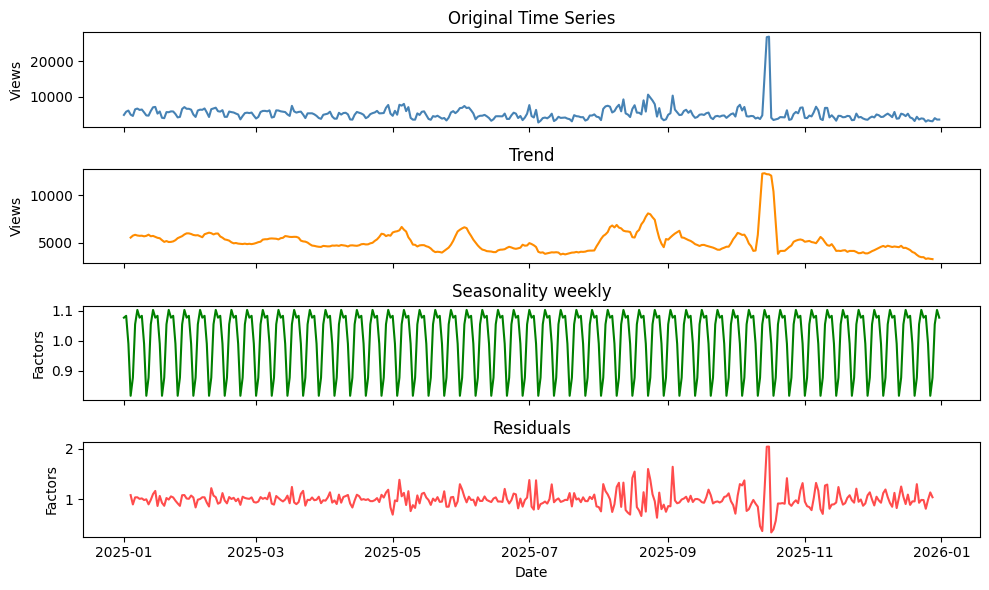

In [ ]:
decomposition = seasonal_decompose(df["views"], model="multiplicative", period=7)

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)

# Original
axes[0].plot(df.index, df["views"], color="steelblue")
axes[0].set_title("Original Time Series", fontsize=12)
axes[0].set_ylabel("Views")

# Trend
axes[1].plot(df.index, decomposition.trend, color="darkorange")
axes[1].set_title("Trend", fontsize=12)
axes[1].set_ylabel("Views")

# Weekly
axes[2].plot(df.index, decomposition.seasonal, color="green")
axes[2].set_title("Seasonality weekly", fontsize=12)
axes[2].set_ylabel("Factors")

# Residuals
axes[3].plot(df.index, decomposition.resid, color="red", alpha=0.7)
axes[3].set_title("Residuals", fontsize=12)
axes[3].set_ylabel("Factors")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

Interpretation:

Time series decomposition can be used to break down the raw data into three components. The **trend** here nicely reflects the fluctuations over time. These could be, for example, specific news items about tech giants relating to AI, but also academic calendars that focus on this topic. On the other hand, holidays, public holidays, etc. also have an influence.

The **seasonal** representation (in this case weekly) shows that the hits are mainly concentrated on working days.

**Residuals** start at factor 1. Only in the second half of the year, and especially at the beginning of the fourth quarter, are outliers visible, which in turn could be attributed to current news.

##3. Trend Estimation
Apply one method: Moving average OR Exponential smoothing

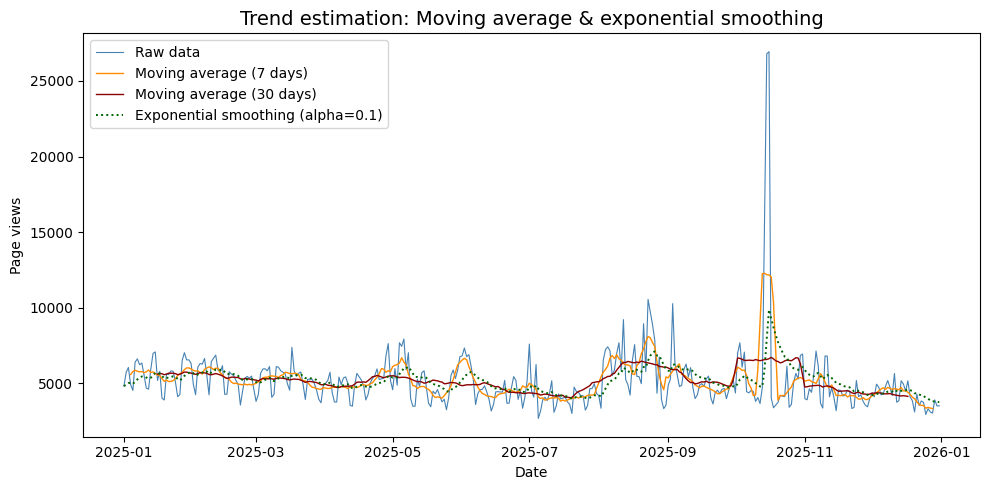

In [ ]:
# Moving average
df["Moving_Average_7"] = df["views"].rolling(window=7, center=True).mean()
df["Moving_Average_30"] = df["views"].rolling(window=30, center=True).mean()

# Exponential smoothing
df["EXS"] = df["views"].ewm(alpha=0.1, adjust=False).mean()

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["views"], color="steelblue", linewidth=0.8, label="Raw data")
plt.plot(df.index, df["Moving_Average_7"], color="darkorange", linewidth=1, label="Moving average (7 days)")
plt.plot(df.index, df["Moving_Average_30"], color="darkred", linewidth=1, label="Moving average (30 days)")
plt.plot(df.index, df["EXS"], color="darkgreen", linewidth=1.4, linestyle=":", label="Exponential smoothing (alpha=0.1)")

plt.title("Trend estimation: Moving average & exponential smoothing", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Page views")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation:

The moving average smooths the time series, as can be seen in the comparison between "7 days" and "30 days", especially at the beginning of the fourth quarter. This is because the calculation window includes all "time neighbours" in the smoothing, as can be seen in the 30-day window. This means that, depending on the time window, short-term trends may be easier to identify. For example, when exactly a shock occurred.

Exponential smoothing (green dotted line) reacts earlier to "more recent" time values, making it faster but still "smoother". As can be seen in the diagram, this line is more meaningful than the "30-day smoothing" but not as striking as the "7-day smoothing".

##4. Simple Forecasting Model
Apply one classical model:

AR OR; ARIMA OR; SARIMA OR; Prophet

Our choice is model: SARIMA

The reason for this is the seasonal pattern in relation to trends.

In [ ]:
# Train/test split (last 30 days as test data)
train = df["views"][:-30]
test = df["views"][-30:]

print(f"training data:  {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test data:      {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

model = SARIMAX(
    train,
    order=(1, 1, 1),              # (AR: 1 day back; difference: 1; MA: take error 1 day back into account)
    seasonal_order=(1, 1, 1, 7),  # (AR: 1 season (7 days) back; difference: t-7; MA: take error 7 days back into account; rhythm: 7 days)
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary())

training data:  335 days (2025-01-01 to 2025-12-01)
Test data:      30 days (2025-12-02 to 2025-12-31)
                                     SARIMAX Results                                     
Dep. Variable:                             views   No. Observations:                  335
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2829.860
Date:                           Wed, 25 Feb 2026   AIC                           5669.720
Time:                                   22:20:16   BIC                           5688.530
Sample:                               01-01-2025   HQIC                          5677.233
                                    - 12-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.60

Interpretation:

In ar.L1 (AR: past and L1: yesterday), it is clear that yesterday's value strongly influences today's value, while ma.L1 (MA: past errors/residuals and L1: yesterday) is subject to significant error correction. In ar.S.L7 (S: seasonal and K7: a week ago), it becomes clear that the same day from the previous week does not correlate (not significant). On the other hand, the error patterns can be corrected well (ma.S.L7), i.e. shocks from the previous week are corrected well.

Ljung box: p = 0.02 (less than 0.05), model does not adequately explain data.

Jarque-Bera (JB): p = 0.00 and therefore not normally distributed (indication of outliers)

##5. Visualization (Important)
Show:
Original vs fitted / forecasted values

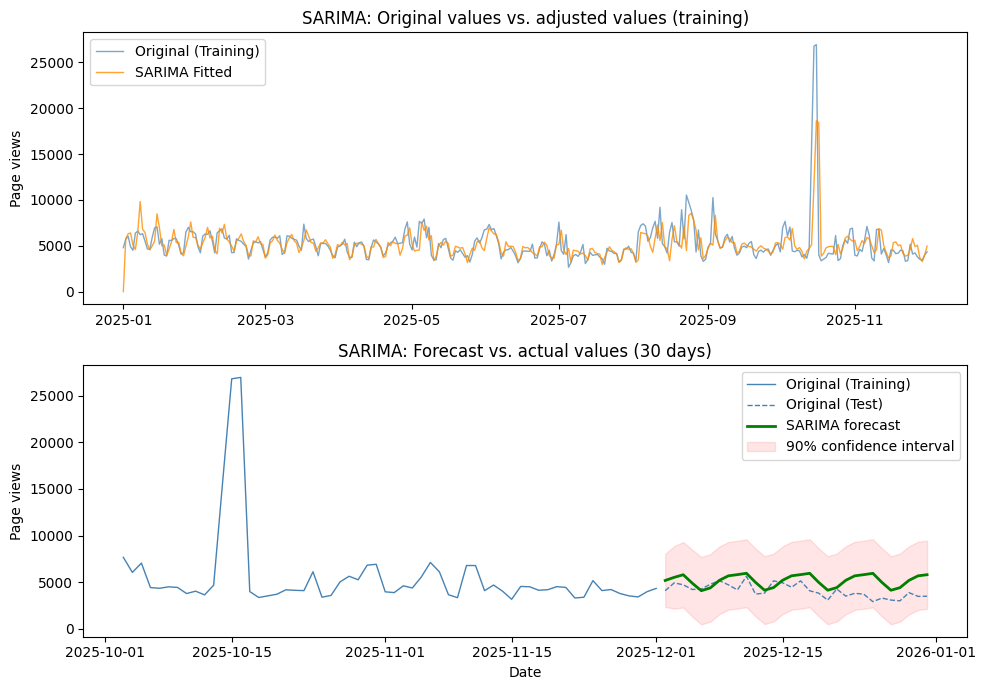

In [ ]:

# Forecast for the trial period (30 days)
forecast = results.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean
forecast_confint = forecast.conf_int(alpha=0.10)

fitted = results.fittedvalues

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Original vs fitted
axes[0].plot(train.index, train, color="steelblue", linewidth=1, label="Original (Training)", alpha=0.7)
axes[0].plot(fitted.index, fitted, color="darkorange", linewidth=1, label="SARIMA Fitted", alpha=0.8)
axes[0].set_title("SARIMA: Original values vs. adjusted values (training)", fontsize=12)
axes[0].set_ylabel("Page views")
axes[0].legend()

# Forecast vs. actual values
axes[1].plot(train.index[-60:], train[-60:], color="steelblue", linewidth=1, label="Original (Training)")
axes[1].plot(test.index, test, color="steelblue", linewidth=1, linestyle="--", label="Original (Test)")
axes[1].plot(forecast_mean.index, forecast_mean, color="green", linewidth=2, label="SARIMA forecast")
axes[1].fill_between(
    forecast_confint.index,
    forecast_confint.iloc[:, 0],
    forecast_confint.iloc[:, 1],
    color="red", alpha=0.1, label="90% confidence interval"
)
axes[1].set_title("SARIMA: Forecast vs. actual values (30 days)", fontsize=12)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Page views")
axes[1].legend()

plt.tight_layout()
plt.show()

Interpretation:

In the first plot, the SARIMA values follow the original curve, but are distorted by outliers and the forecast tends to rise.

In the second plot, forecasts are compared with the test data. The test shows that the model still overestimates itself (see coloured area above the dotted blue line). This is likely to be due to the outlier in October.